In [ ]:
import echopype as ep
import matplotlib.pyplot as plt
import datetime
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
#USE echopype_env on oceanica_joan folder!

#NOTES:
#.bot files for EK60 sonars are not used by echpype, not implemented


In [ ]:

#FileName = 'D20110113-T105327'
#FileName = 'D20110113-T074949'
FileName = 'D20110113-T105327'
rawFileDate = datetime.datetime(int(FileName[1:5]), int(FileName[5:7]), int(FileName[7:9]))


In [ ]:
#1. Load the raw data
# # for EK60 file
ed = ep.open_raw("../data/MALASPINA_LEG1/" + FileName + '.raw', sonar_model="EK60")  # for EK60 file


In [ ]:
ed

In [35]:
ed_Sv = ep.calibrate.compute_Sv(ed)
ed_Sv = ep.consolidate.add_depth(ed_Sv)

<Figure size 1400x600 with 0 Axes>

Text(0.5, 0, 'Ping time')

Text(0, 0.5, 'True depth (m)')

Text(0.5, 1.0, 'EK60 Echogram — True Depth (slant range + draft correction)')

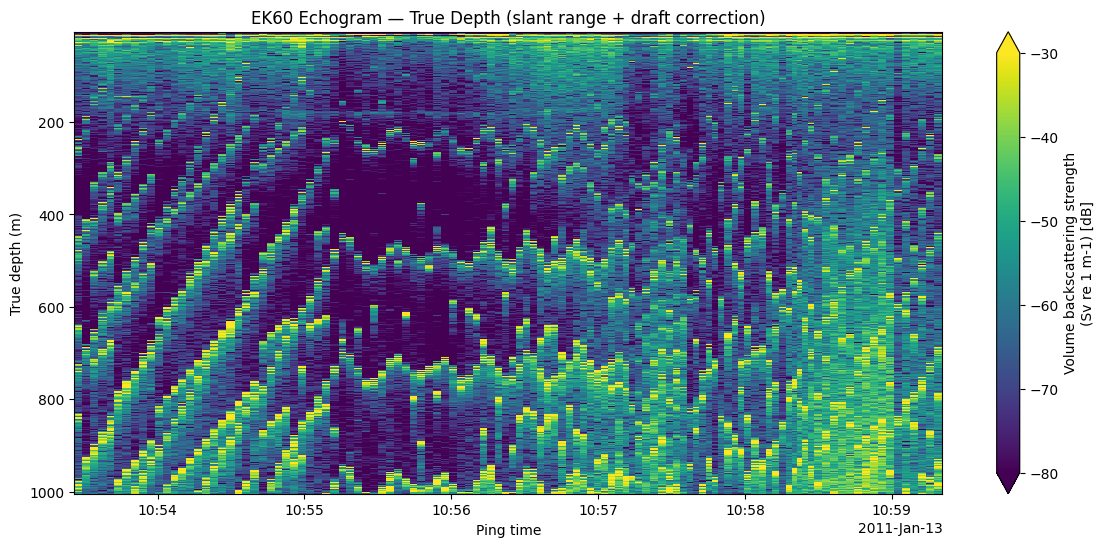

In [58]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

channel = ed_Sv.channel.values[0]

# Extract Sv and echo_range
sv = ed_Sv.Sv.sel(channel=channel)
echo_range = ed_Sv.echo_range.sel(channel=channel)

# Draft / transducer depth
draft = float(ed_Sv.water_level.values)   # = 4.5 m

# Compute true depth
true_depth = echo_range + draft

# Align arrays
sv, true_depth = xr.align(sv, true_depth)

# Attach true depth as coordinate
sv = sv.assign_coords(depth=true_depth)

# Plot
plt.figure(figsize=(14,6))
sv.plot(
    x="ping_time",
    y="depth",
    vmin=-80, vmax=-30,
    cmap="viridis"
)
plt.gca().invert_yaxis()
plt.xlabel("Ping time")
plt.ylabel("True depth (m)")
plt.title("EK60 Echogram — True Depth (slant range + draft correction)")
plt.show()


In [57]:
print(ed["Platform"].data_vars)

Data variables:
    latitude             (time1) float64 3kB -22.89 -22.89 ... -22.9 -22.9
    longitude            (time1) float64 3kB -43.2 -43.2 -43.2 ... -43.21 -43.21
    sentence_type        (time1) <U3 4kB 'GGA' 'GGA' 'GGA' ... 'GGA' 'GGA' 'GGA'
    pitch                (time2) float64 928B 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    roll                 (time2) float64 928B 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    vertical_offset      (time2) float64 928B 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    water_level          float64 8B 4.5
    MRU_offset_x         float64 8B nan
    MRU_offset_y         float64 8B nan
    MRU_offset_z         float64 8B nan
    MRU_rotation_x       float64 8B nan
    MRU_rotation_y       float64 8B nan
    MRU_rotation_z       float64 8B nan
    position_offset_x    float64 8B nan
    position_offset_y    float64 8B nan
    position_offset_z    float64 8B nan
    transducer_offset_x  (channel) float64 8B 0.0
    transducer_offset_y  (channel) float64 8B 0.0
    transduce

In [54]:
import pandas as pd
lat = ed["Platform"]["latitude"].values
lon = ed["Platform"]["longitude"].values
time = ed["Platform"]["time1"].values

df = pd.DataFrame({
    "time": time,
    "latitude": lat,
    "longitude": lon
})

df.to_csv('coords_' + FileName +'.csv')


In [162]:
import struct
import numpy as np
from datetime import datetime, timedelta

FILETIME_EPOCH = datetime(1601, 1, 1)

def filetime_to_datetime(filetime_int):
    """Convert 64-bit Windows FILETIME to Python datetime."""
    return FILETIME_EPOCH + timedelta(microseconds=filetime_int / 10)

def parse_ek60_bot(botfile):
    RECORD = 848
    BLOCK = 28  # Correct BOT0 block size
    TAG = b'BOT0'
    
    times = []
    depths = []
    
    with open(botfile, "rb") as f:
        f.read(RECORD)  # skip header
        
        while True:
            rec = f.read(RECORD)
            if len(rec) < RECORD:
                break
            
            for pos in range(0, RECORD - BLOCK, 1):  # scan byte-by-byte
                if rec[pos+4:pos+8] == TAG:
                    
                    # timestamp (uint64)
                    ts_raw = struct.unpack('<Q', rec[pos+8:pos+16])[0]
                    ts = filetime_to_datetime(ts_raw)
                    
                    # depth (float64)
                    depth = struct.unpack('<d', rec[pos+20:pos+28])[0]
                    
                    times.append(ts)
                    depths.append(depth)
    
    return np.array(times), np.array(depths)

times, bottom = parse_ek60_bot("../data/MALASPINA_LEG1/" + FileName +".bot")

print(times[:5])
print(bottom[:5])



[datetime.datetime(2011, 1, 13, 10, 53, 27, 695962)
 datetime.datetime(2011, 1, 13, 10, 53, 30, 984608)
 datetime.datetime(2011, 1, 13, 10, 53, 34, 257668)
 datetime.datetime(2011, 1, 13, 10, 53, 37, 530728)
 datetime.datetime(2011, 1, 13, 10, 53, 40, 803788)]
[0. 0. 0. 0. 0.]


<Figure size 1200x600 with 0 Axes>

Text(0.5, 0, 'Time')

Text(0, 0.5, 'Depth (m)')

Text(0.5, 1.0, 'Echogram with depth from echopype.add_depth()')

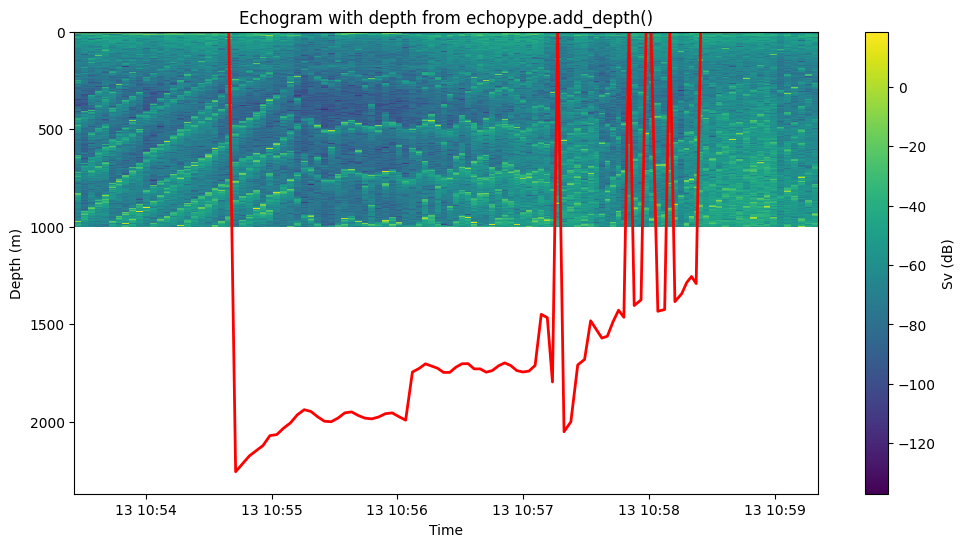

In [163]:
plt.figure(figsize=(12,6))
plt.pcolormesh(
    ed_Sv['ping_time'],
    depth,
    Sv_data.T,            # (range_sample, ping_time) .T is transposing array dimensions
    cmap="viridis",
    shading="auto"
)
plt.plot(times, bottom, "r-", linewidth=2)
plt.gca().invert_yaxis()
plt.xlabel("Time")
plt.ylabel("Depth (m)")
plt.colorbar(label="Sv (dB)")
plt.title("Echogram with depth from echopype.add_depth()")
plt.show()

KeyError: "No variable named 'Platform'. Variables on the dataset include ['channel', 'ping_time', 'range_sample', 'Sv', 'echo_range', ..., 'beamwidth_athwartship', 'source_filenames', 'filenames', 'water_level', 'depth']"